# Step 1 : Importing, Loading, and Dicovering


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, PowerTransformer, StandardScaler

import plotly.graph_objects as go


import joblib

# ◉ Project Data Dictionary
## ◉ Household Socioeconomic & Demographic Features

---

| Feature | Description |
|:---|:---|
| **Rural or Urban** | Indicates whether the household is located in a rural or urban area. |
| **Housing Type** | The type of housing (owned, rented, informal, shared). |
| **Monthly Income** | The total monthly income of the household in EGP. |
| **Income Stability** | Describes whether the income is **Stable** or **Unstable** (Irregular). |
| **Income Source** | The primary source of income (Salary, Daily Wage, Pension, Social Aid). |
| **Expenses Estimate** | The estimated total monthly expenses of the household. |
| **Has Debt** | Binary indicator (Yes / No) of current outstanding debt. |
| **Debt Amount** | The total amount of debt (Recorded as 0 if "Has Debt" is No). |
| **Education Level** | The highest level of education attained by the head of the household. |
| **Literacy** | Indicates whether the household head can read and write (Yes / No). |
| **Employment Status** | Current work condition (Employed, Irregular Worker, or Unemployed). |
| **Skills** | Vocational expertise (Tailoring, Agriculture, Driving, Carpentry). |
| **Family Size** | The total number of members living in the household. |
| **Children in School** | The number of children currently attending school. |
| **Chronic Disease** | Indicates if any member has a long-term illness (Yes / No). |
| **Disabled Member** | Indicates if the household includes a member with a disability. |
| **Medical Cost** | Estimated monthly healthcare and medication expenses. |
| **Willing to Work** | Household's readiness to join Sanad's empowerment projects. |

---
**Note:** *All financial values are recorded in Egyptian Pounds (EGP).*

---

In [3]:
df = pd.read_csv("D:\Data-Science Projects\DEPI graduation project\Sanad_Data_v2.csv")
df.head()

,full_name,gender,ssn,phone_number,age,family_size,number_of_children,governorate,center,village,...,years_of_experience,skills,has_stable_job,willing_to_work,has_previous_business,has_savings,owns_assets,access_to_water,access_to_electricity,application_date
0,Hussein Mahmoud Khaled El-Badawy,Male,29814928731062,'01539921804,28,6,2,Cairo,El Marg,New Marg,...,4,Carpentry,No,Yes,No,Yes,Yes,No,Yes,6/30/2025
1,Wafaa Mohamed Yassin Ghanem,Female,27573701997557,'01178121927,51,3,6,Giza,Dokki,Bein El Sarayat,...,0,Agriculture,Yes,No,No,No,Yes,Yes,Yes,2/21/2025
2,Aisha Mustafa Mahmoud Salem,Female,29954177515698,'01588866231,27,4,3,Minya,Maghagha,Sharona,...,5,Driving,No,No,No,No,No,Yes,Yes,8/28/2024
3,Ziad Kareem Ahmed El-Shafei,Male,28063423924084,'01187326779,46,10,2,Giza,Haram,Meshal,...,0,Cooking,Yes,No,No,Yes,Yes,Yes,Yes,5/24/2025
4,Kareem Yassin Youssef Salem,Male,27450083437779,'01154427173,52,5,1,Cairo,Kafr El Dawar,Sidi Ghazi,...,13,Agriculture,No,Yes,No,No,No,Yes,Yes,6/14/2024


In [4]:
df.head().T

,0,1,2,3,4
full_name,Hussein Mahmoud Khaled El-Badawy,Wafaa Mohamed Yassin Ghanem,Aisha Mustafa Mahmoud Salem,Ziad Kareem Ahmed El-Shafei,Kareem Yassin Youssef Salem
gender,Male,Female,Female,Male,Male
ssn,29814928731062,27573701997557,29954177515698,28063423924084,27450083437779
phone_number,'01539921804,'01178121927,'01588866231,'01187326779,'01154427173
age,28,51,27,46,52
family_size,6,3,4,10,5
number_of_children,2,6,3,2,1
governorate,Cairo,Giza,Minya,Giza,Cairo
center,El Marg,Dokki,Maghagha,Haram,Kafr El Dawar
village,New Marg,Bein El Sarayat,Sharona,Meshal,Sidi Ghazi


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   full_name              50000 non-null  object
 1   gender                 50000 non-null  object
 2   ssn                    50000 non-null  int64 
 3   phone_number           50000 non-null  object
 4   age                    50000 non-null  int64 
 5   family_size            50000 non-null  int64 
 6   number_of_children     50000 non-null  int64 
 7   governorate            50000 non-null  object
 8   center                 50000 non-null  object
 9   village                50000 non-null  object
 10  rural_or_urban         50000 non-null  object
 11  housing_type           50000 non-null  object
 12  monthly_income         50000 non-null  int64 
 13  income_stability       50000 non-null  object
 14  income_source          50000 non-null  object
 15  expenses_estimate  

In [6]:
df['skills'].unique()

array(['Carpentry', 'Agriculture', 'Driving', 'Cooking', 'Tailoring',
       'Plumbing'], dtype=object)

#### There are some **nans** in the skills column which probably mean that the applicant doesn't have a job or a skill.

In [7]:
df.describe()

,ssn,age,family_size,number_of_children,monthly_income,expenses_estimate,debt_amount,children_in_school,medical_cost_estimate,years_of_experience
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2.789979e+13,47.503140,6.303680,2.228260,5197.272700,4723.597640,6996.929820,1.894060,770.504740,10.975860
std,1.105285e+12,11.049382,2.435154,1.680706,3488.862173,2513.544159,10927.764885,1.525583,1410.615424,10.826426
min,2.510009e+13,20.000000,1.000000,0.000000,432.000000,1000.000000,0.000000,0.000000,0.000000,0.000000
25%,2.733024e+13,42.000000,4.000000,1.000000,2764.000000,2863.000000,0.000000,1.000000,0.000000,1.000000
50%,2.789728e+13,48.000000,6.000000,2.000000,4345.500000,4347.500000,0.000000,2.000000,0.000000,8.000000
75%,2.847560e+13,53.000000,8.000000,3.000000,6638.000000,6172.000000,12377.250000,3.000000,998.250000,18.000000
max,3.069987e+13,75.000000,10.000000,8.000000,36561.000000,24201.000000,49978.000000,8.000000,5000.000000,55.000000


---

# Step 2 : Data Cleaning

### Checking for outliers.

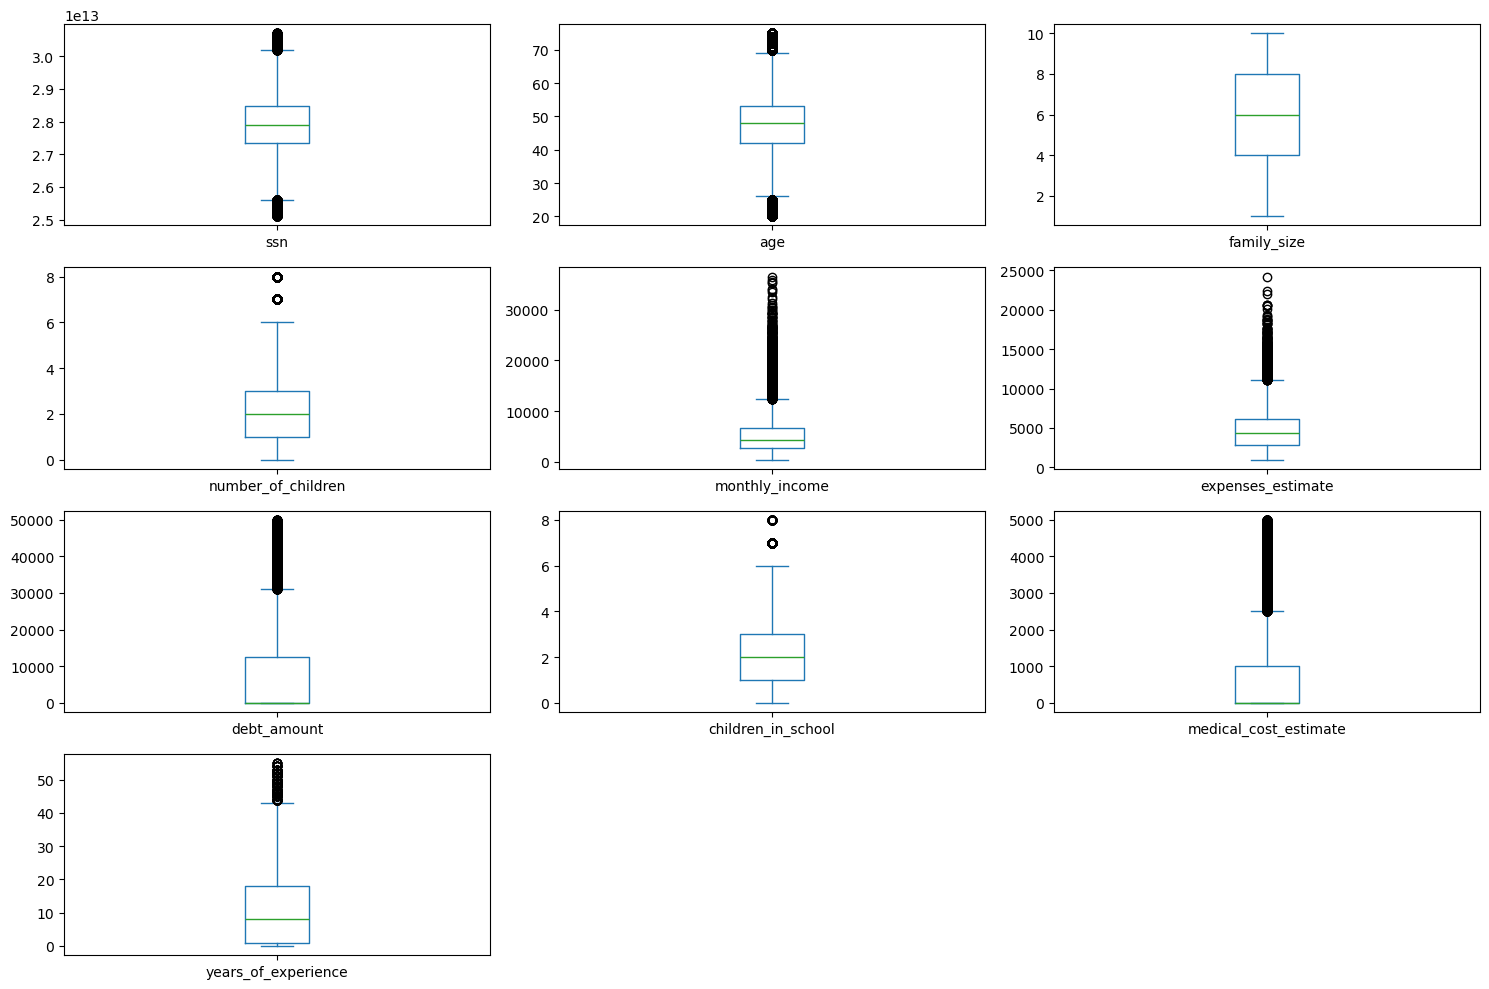

In [8]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].plot(
    kind='box',
    subplots=True,
    layout=(len(num_cols)//3 + 1, 3),
    figsize=(15, 10)
)

plt.tight_layout()
plt.show()

- This visualization identifies extreme values (outliers) across all numerical features like Income, Debt, and Expenses. It helps us detect potential data entry errors or extremely wealthy/poor cases that stand out from the general population


- We will use these plots to decide which outliers represent real life like (very high debt) and which are likely errors. If an outlier is an error, we will remove it. If it is real but too extreme, we might use log-transformation to prevent it from confusing our Machine Learning models later.

### Data Type Conversion

In [9]:
df["application_date"] = pd.to_datetime(df["application_date"])

### Check Duplicates

In [10]:
df.duplicated().any()

np.False_

---

# Exploratory Data Analysis ( EDA )

## Univariate Analysis

In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols].describe()

,ssn,age,family_size,number_of_children,monthly_income,expenses_estimate,debt_amount,children_in_school,medical_cost_estimate,years_of_experience
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2.789979e+13,47.503140,6.303680,2.228260,5197.272700,4723.597640,6996.929820,1.894060,770.504740,10.975860
std,1.105285e+12,11.049382,2.435154,1.680706,3488.862173,2513.544159,10927.764885,1.525583,1410.615424,10.826426
min,2.510009e+13,20.000000,1.000000,0.000000,432.000000,1000.000000,0.000000,0.000000,0.000000,0.000000
25%,2.733024e+13,42.000000,4.000000,1.000000,2764.000000,2863.000000,0.000000,1.000000,0.000000,1.000000
50%,2.789728e+13,48.000000,6.000000,2.000000,4345.500000,4347.500000,0.000000,2.000000,0.000000,8.000000
75%,2.847560e+13,53.000000,8.000000,3.000000,6638.000000,6172.000000,12377.250000,3.000000,998.250000,18.000000
max,3.069987e+13,75.000000,10.000000,8.000000,36561.000000,24201.000000,49978.000000,8.000000,5000.000000,55.000000


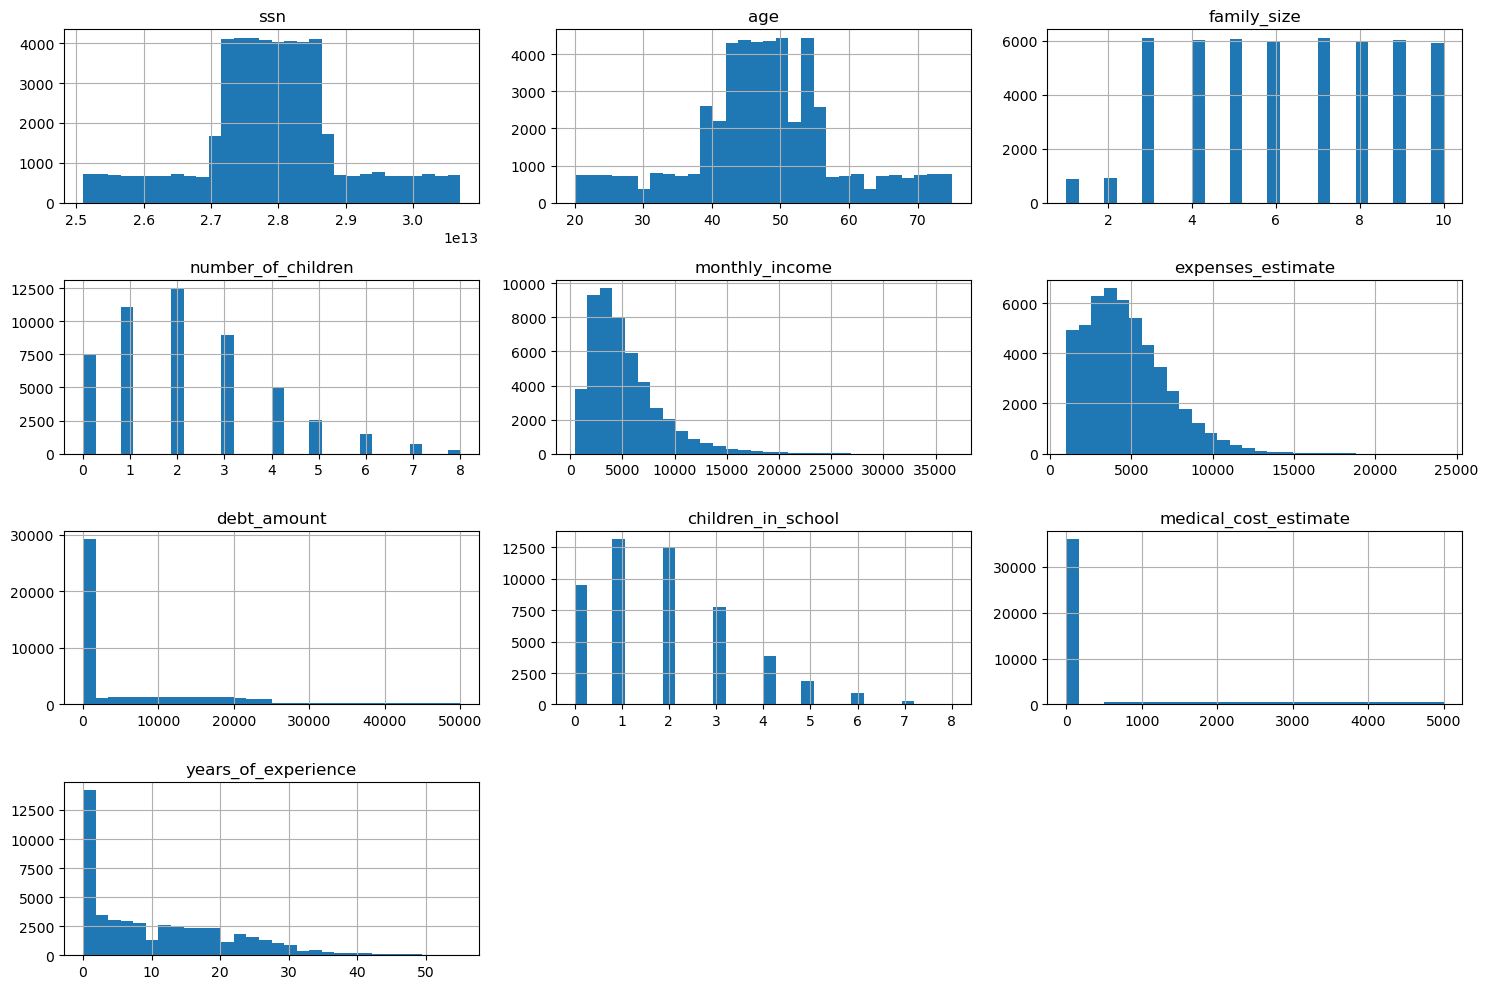

In [12]:
df[num_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

In [13]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols].describe()

,full_name,gender,phone_number,governorate,center,village,rural_or_urban,housing_type,income_stability,income_source,...,disabled_member,employment_status,skills,has_stable_job,willing_to_work,has_previous_business,has_savings,owns_assets,access_to_water,access_to_electricity
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,...,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,46311,2,49995,10,31,58,2,4,2,4,...,2,3,6,2,2,2,2,2,2,2
top,Hussein Yassin Selim Morsi,Female,'01150797429,Cairo,Ashmoun,Rawda,Urban,Owned,Stable,Social Aid,...,No,Irregular Worker,Tailoring,No,Yes,No,No,No,Yes,Yes
freq,4,25188,2,12206,1739,2593,30037,19999,26908,12566,...,44987,20202,12467,36858,29973,42699,33559,27425,47653,48503


- Female applicants are more than male applicants. p(female) = 50.38% ----- p(male) = 49.61% --- However, It is actually balanced.

- Most applicants are from Sharqia. P(Cairo) = 29.85%

- If Unique is too high for some columns, we might group small categories together to make the Machine Learning model more accurate

- There are 5 identical phone numbers, and these are odd values. The number of rows is not large, so we will delete them.

In [14]:
df = df.drop_duplicates(subset=['phone_number'], keep='first')
print(f"Total rows after cleaning phone duplicates:{len(df)}")

Total rows after cleaning phone duplicates:49995


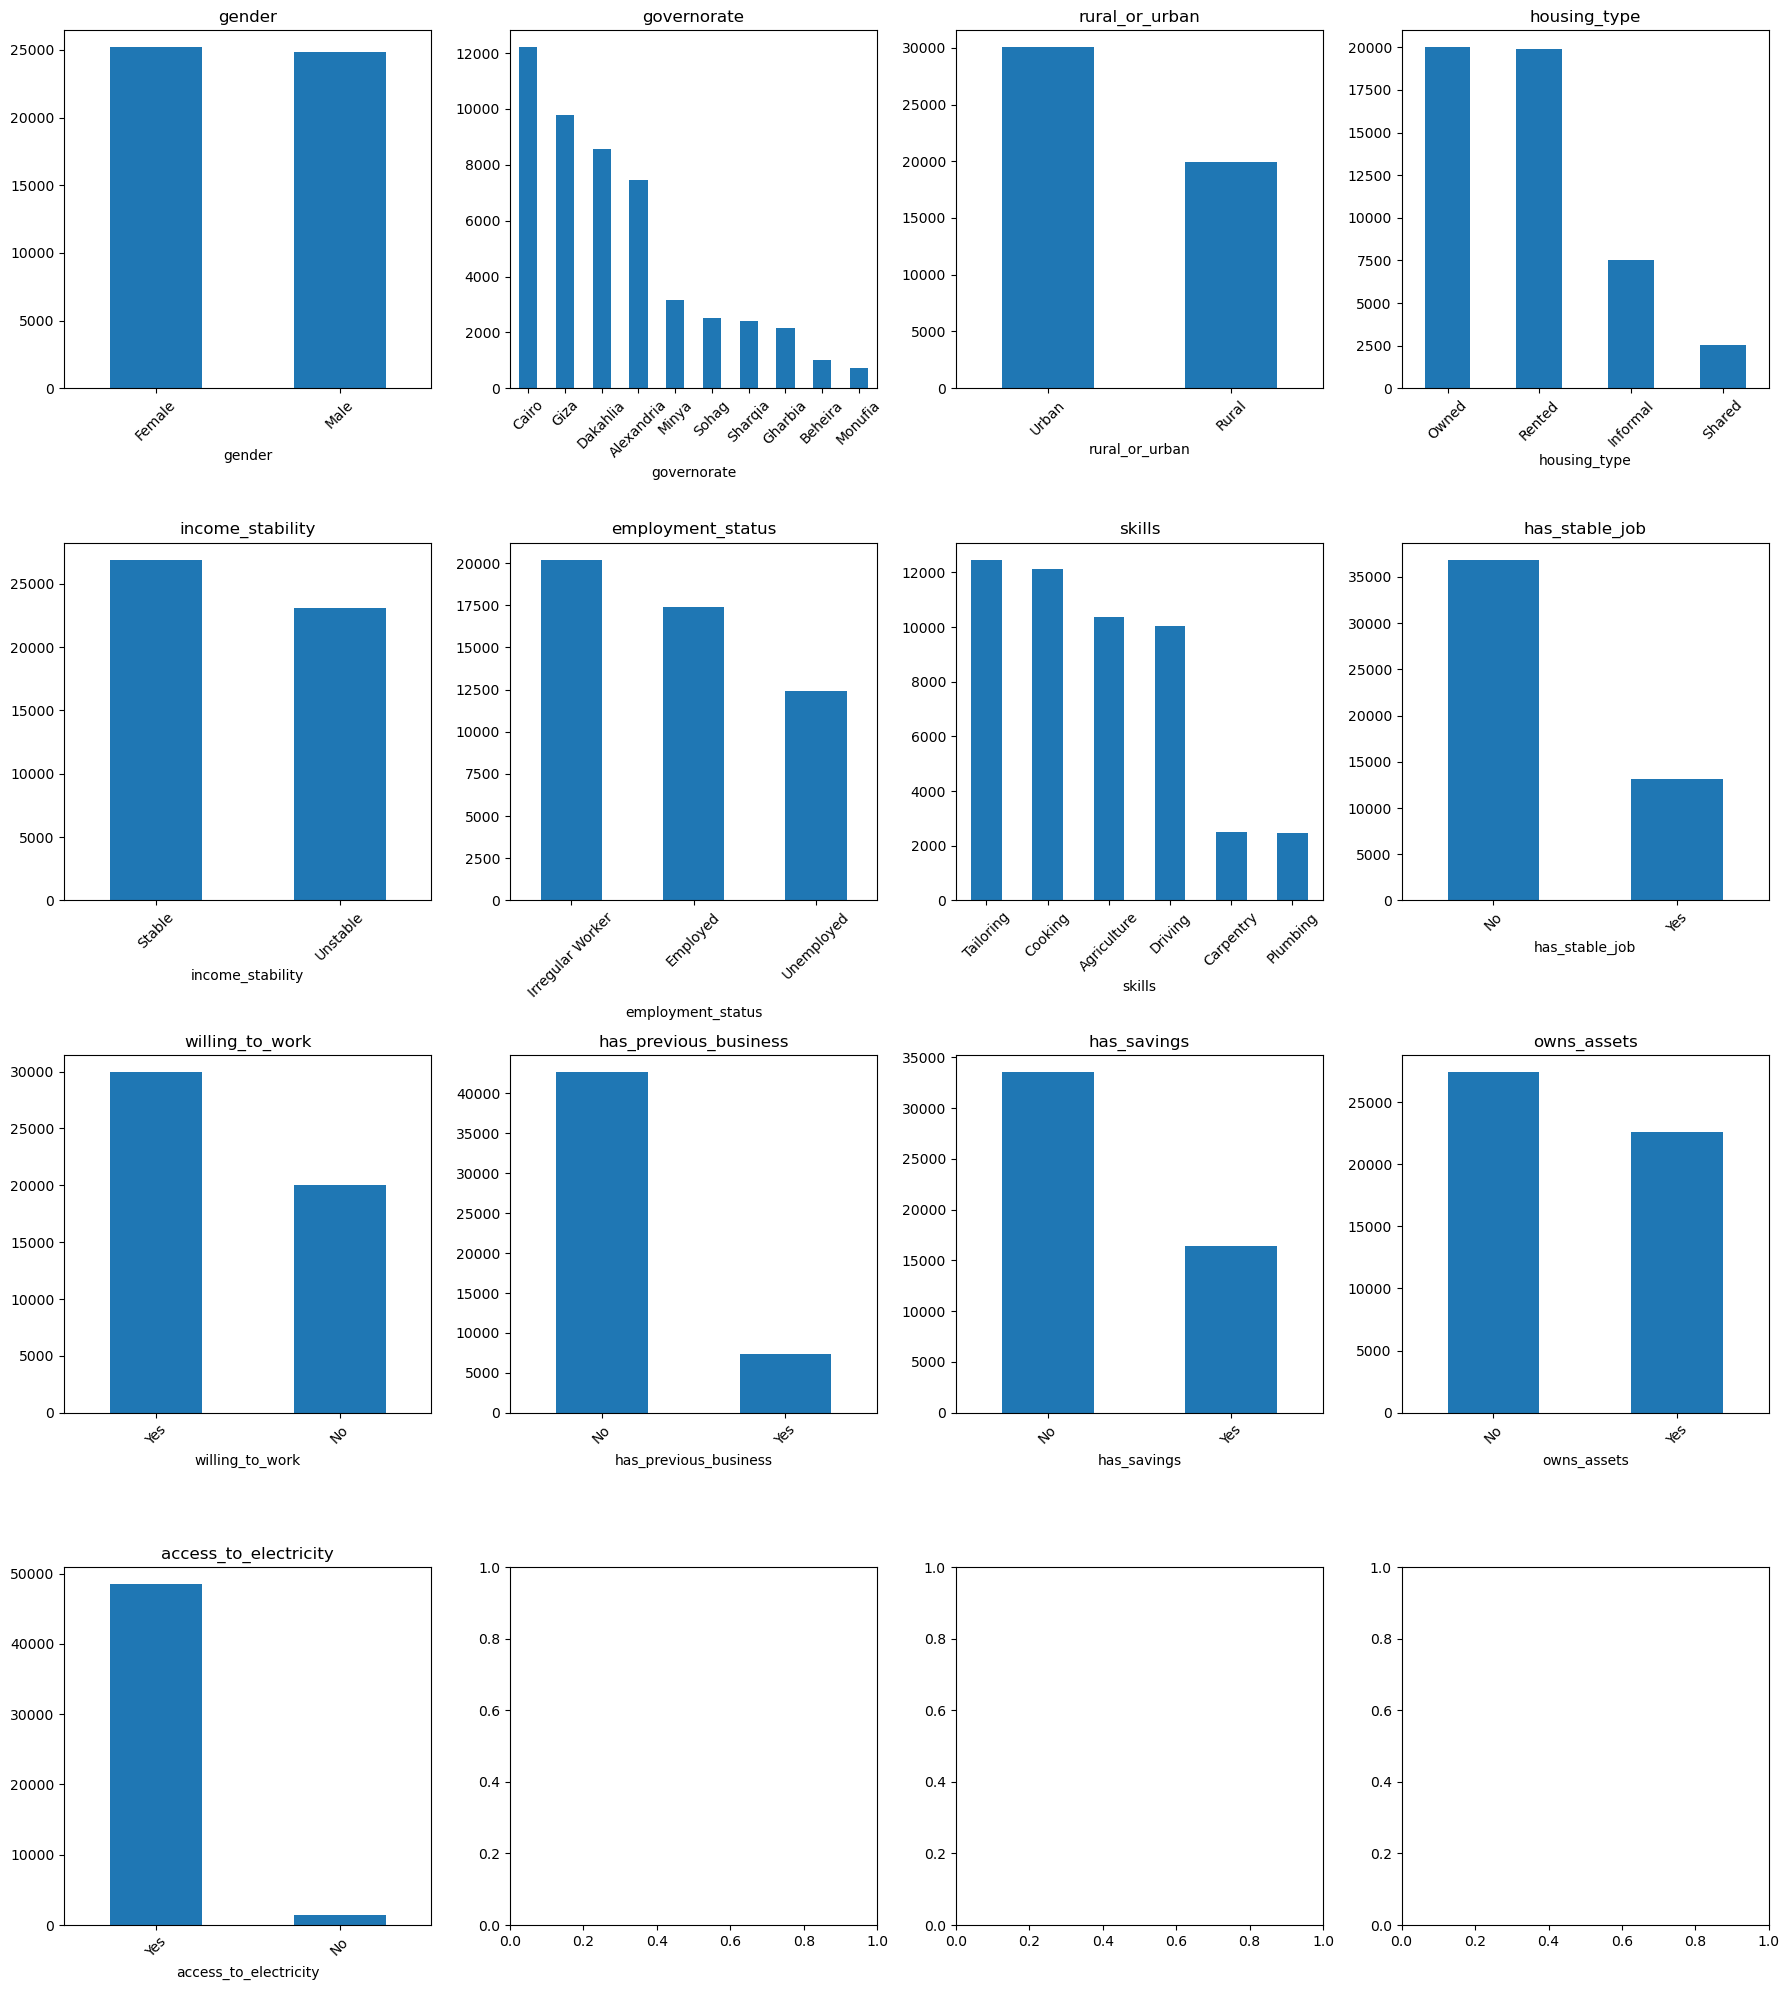

In [15]:
cat1_cols = ['gender','governorate','rural_or_urban','housing_type','income_stability','employment_status','skills','has_stable_job','willing_to_work','has_previous_business','has_savings','owns_assets','access_to_electricity',]


n_cols = 4
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat1_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

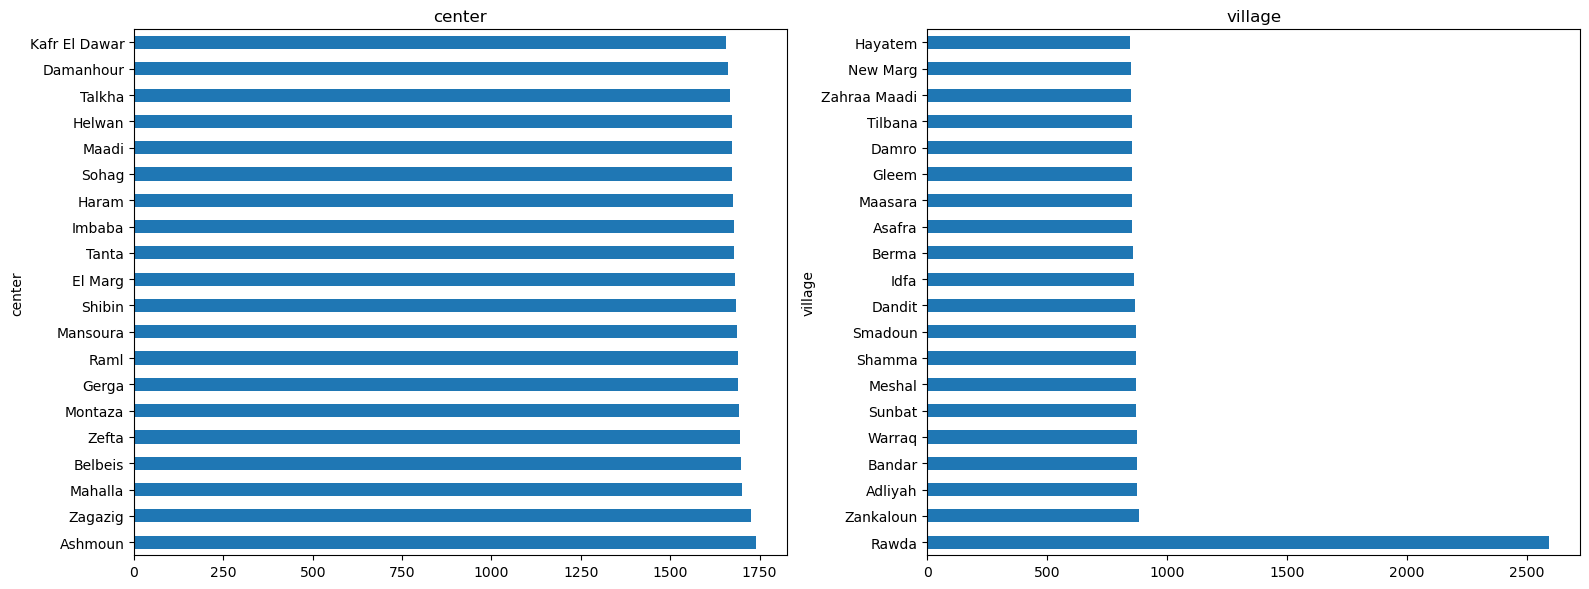

In [16]:
catt = ['center', 'village']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, col in enumerate(catt):
    df[col].value_counts().head(20).plot(kind='barh', ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

- This chart identifies the geographic "hotspots" of our target population. It shows exactly which administrative centers and specific villages have the highest number of families requesting support.  

- *Deep Dive into "Rawda":* We need to investigate why "Rawda" village has a significantly higher number of applications compared to all other villages. This could be due to higher poverty levels in that specific area or better awareness of our services there.

### **Bivariate Analysis**

- ### 1) Numeric ↔ Numeric
  - monthly_income ↔ expenses_estimate
  - family_size ↔ expenses_estimate

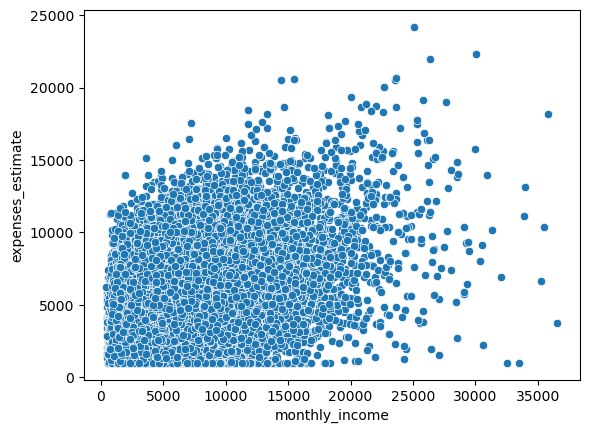

In [17]:
sns.scatterplot(data=df, x='monthly_income', y='expenses_estimate')
plt.show()

Text(0.5, 1.0, 'Expenses Distribution by Family Size')

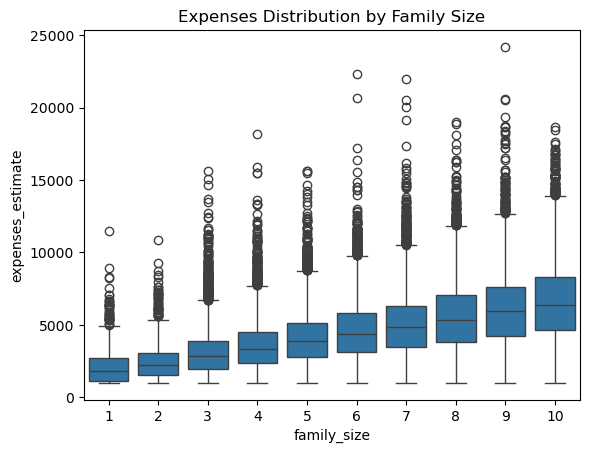

In [18]:
sns.boxplot(data=df, x='family_size', y='expenses_estimate')
plt.title('Expenses Distribution by Family Size')

- ### 2) Numeric ↔ Categorical
  - rural_or_urban ↔ monthly_income
  - education_level_head ↔ monthly_income
  - employment_status ↔ monthly_income
  - has_debt ↔ monthly_income
  - has_savings ↔ monthly_income
  - chronic_disease ↔ medical_cost_estimate
  - disabled_member ↔ medical_cost_estimate

Text(0.5, 1.0, 'Income Distribution: Rural vs Urban')

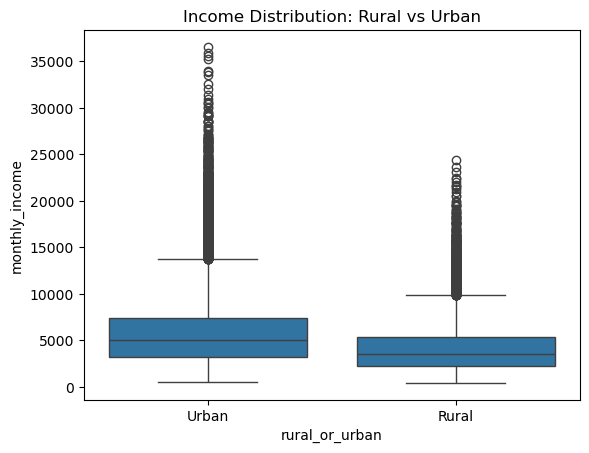

In [19]:
sns.boxplot(data=df, x='rural_or_urban', y='monthly_income')
plt.title('Income Distribution: Rural vs Urban')

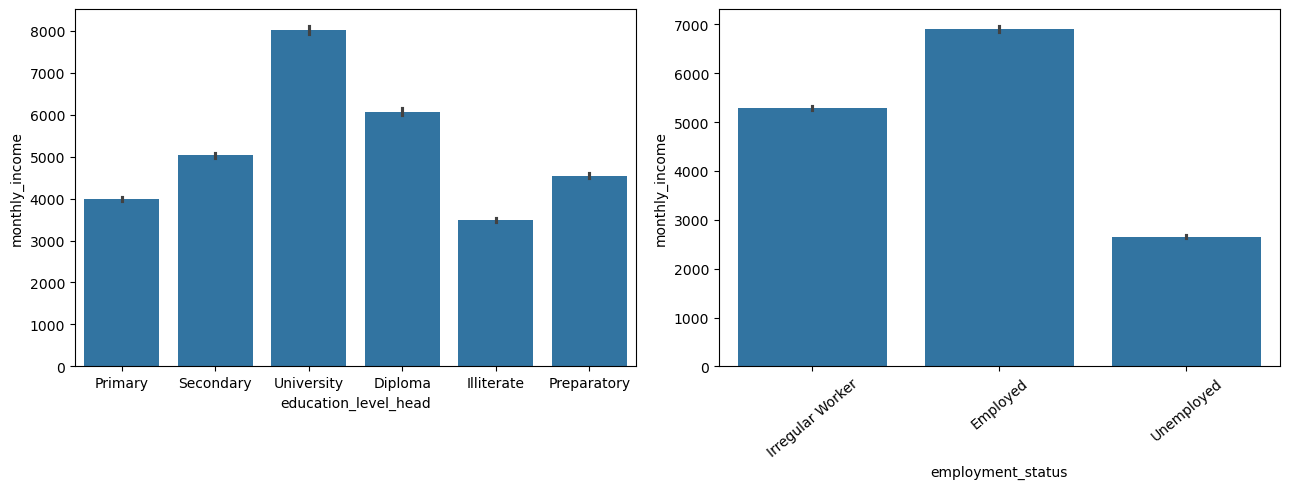

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(ax=axes[0], data=df, x='education_level_head', y='monthly_income', estimator=np.mean)
sns.barplot(ax=axes[1], data=df, x='employment_status', y='monthly_income', estimator=np.mean)

plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

<Axes: xlabel='has_savings', ylabel='monthly_income'>

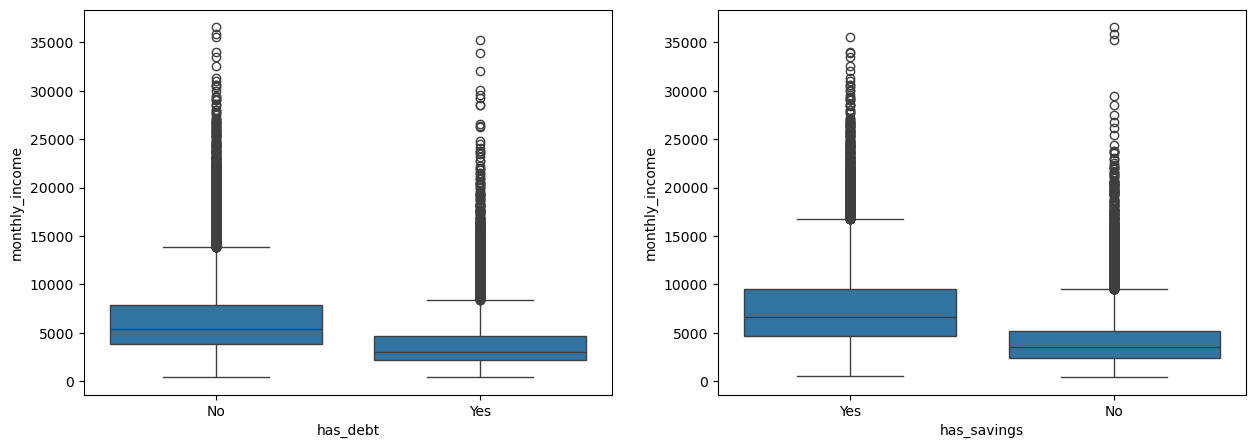

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], data=df, x='has_debt', y='monthly_income')
sns.boxplot(ax=axes[1], data=df, x='has_savings', y='monthly_income')

Text(0.5, 1.0, 'Impact of Chronic Diseases on Medical Costs')

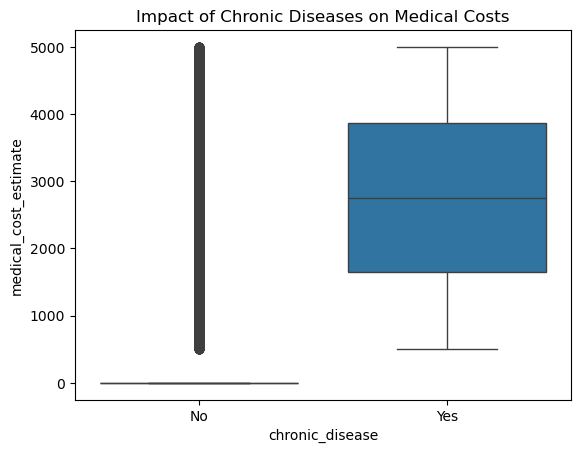

In [22]:
sns.boxplot(data=df, x='chronic_disease', y='medical_cost_estimate')
plt.title('Impact of Chronic Diseases on Medical Costs')

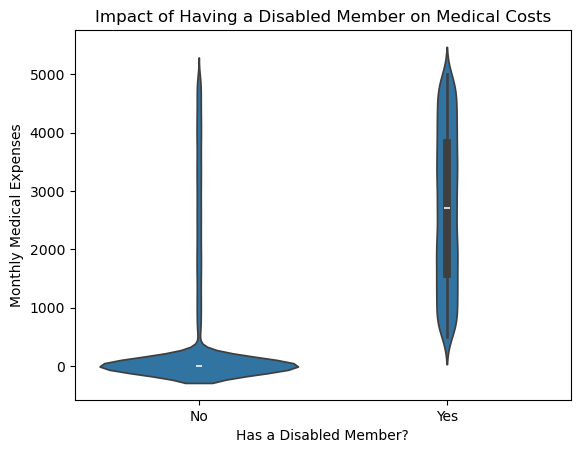

In [23]:
sns.violinplot(data=df, x='disabled_member', y='medical_cost_estimate')

plt.title('Impact of Having a Disabled Member on Medical Costs')
plt.xlabel('Has a Disabled Member?')
plt.ylabel('Monthly Medical Expenses')
plt.show()

- ### 3) Categorical ↔ Categorical
  - rural_or_urban ↔ has_debt
  - income_stability ↔ has_debt
  - has_savings ↔ owns_assets
  - employment_status ↔ has_debt

Text(0, 0.5, 'Count')

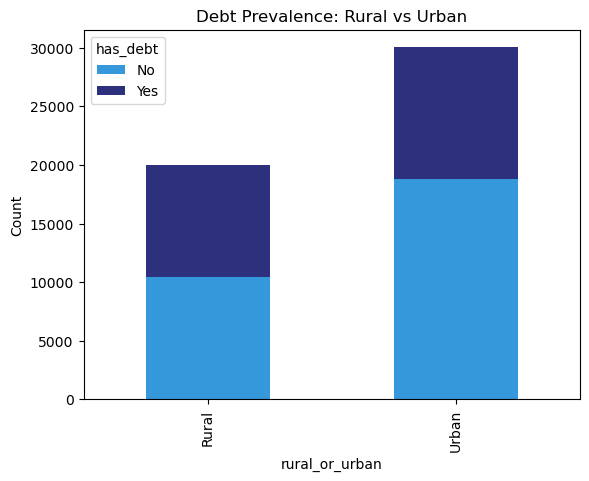

In [24]:
pd.crosstab(df['rural_or_urban'], df['has_debt']).plot(kind='bar', stacked=True, color=['#3498db', "#2d317d"])
plt.title('Debt Prevalence: Rural vs Urban')
plt.ylabel('Count')

Text(0.5, 1.0, 'Income Stability vs Debt (Percentage)')

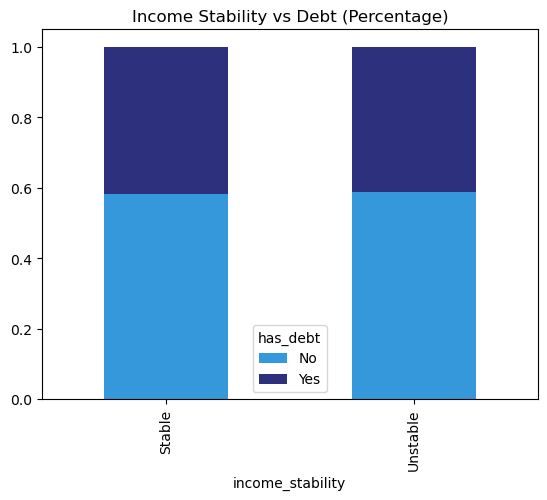

In [25]:
stability_debt = pd.crosstab(df['income_stability'], df['has_debt'], normalize='index')
stability_debt.plot(kind='bar', stacked=True, color=['#3498db', "#2d317d"])
plt.title('Income Stability vs Debt (Percentage)')

Text(0.5, 1.0, 'Savings vs Asset Ownership')

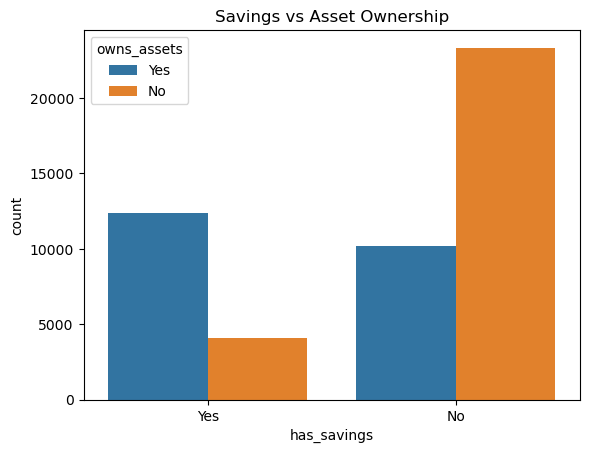

In [26]:
sns.countplot(data=df, x='has_savings', hue='owns_assets')
plt.title('Savings vs Asset Ownership')

Text(0.5, 1.0, 'Debt Status by Employment Type')

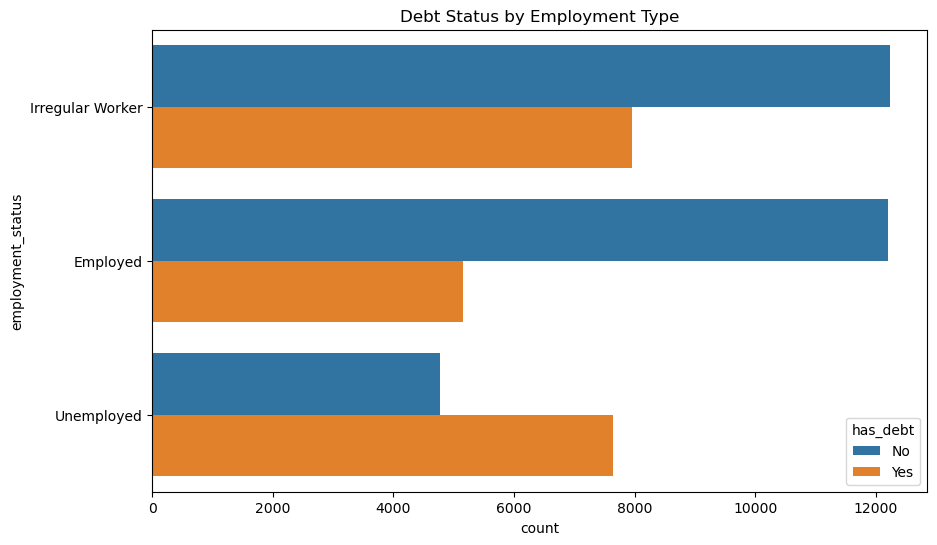

In [27]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='employment_status', hue='has_debt')
plt.title('Debt Status by Employment Type')

-----------------------------
*****************************
-----------------------------

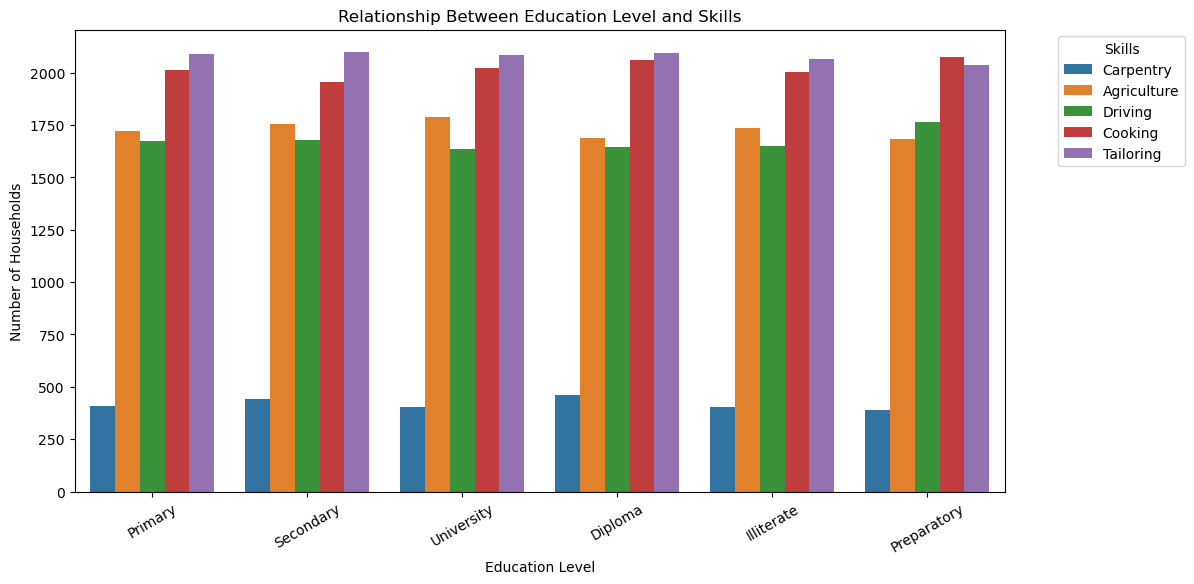

In [28]:
# Education Level vs Top 5 Skills

top_skills = df['skills'].value_counts().nlargest(5).index
filtered_df = df[df['skills'].isin(top_skills)]

plt.figure(figsize=(12, 6))
sns.countplot(data=filtered_df, x='education_level_head', hue='skills')

plt.title('Relationship Between Education Level and Skills')
plt.xlabel('Education Level')
plt.ylabel('Number of Households')
plt.legend(title='Skills', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=30)
plt.show()

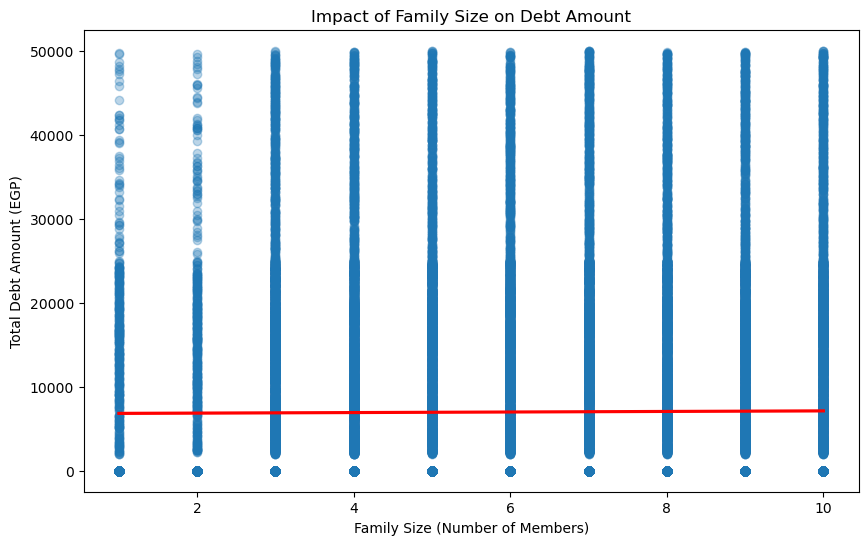

In [29]:
# Family Size vs Debt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.regplot(data=df, x='family_size', y='debt_amount', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Impact of Family Size on Debt Amount')
plt.xlabel('Family Size (Number of Members)')
plt.ylabel('Total Debt Amount (EGP)')
plt.show()

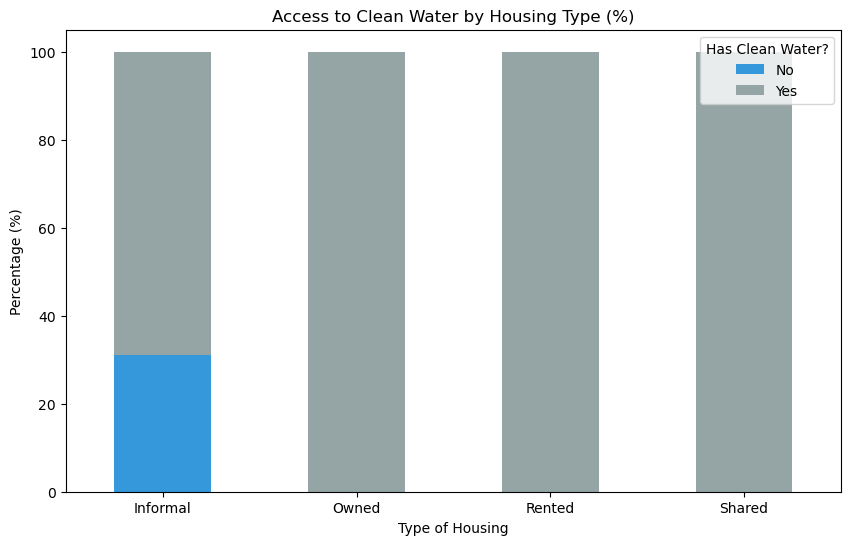

In [30]:
# Housing Type vs Access to Water

housing_water = pd.crosstab(df['housing_type'], df['access_to_water'], normalize='index') * 100

housing_water.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#3498db', '#95a5a6'])

plt.title('Access to Clean Water by Housing Type (%)')
plt.ylabel('Percentage (%)')
plt.xlabel('Type of Housing')
plt.xticks(rotation=0)
plt.legend(title='Has Clean Water?', loc='upper right')
plt.show()

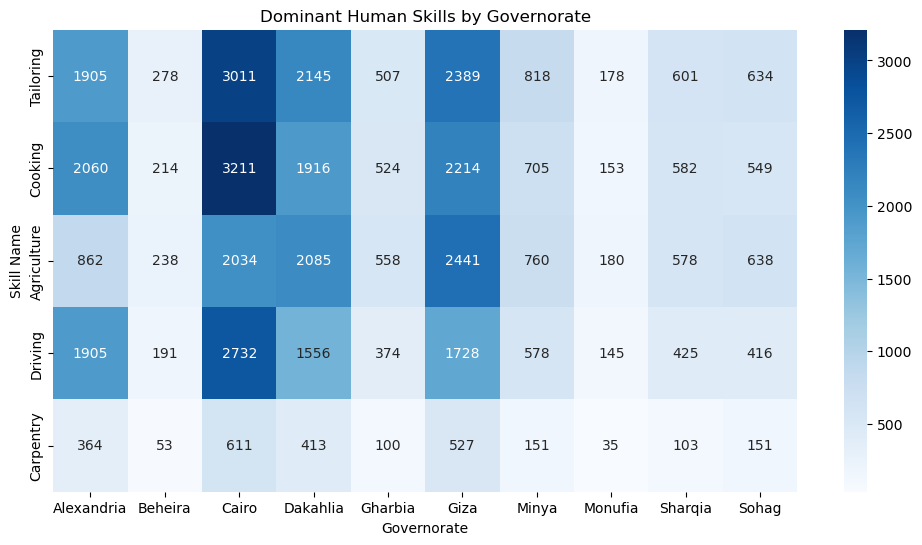

In [31]:
# Top 5 Skills Mapping
plt.figure(figsize=(12, 6))
top_skills = df['skills'].value_counts().nlargest(5).index
skills_matrix = df.groupby(['governorate', 'skills']).size().unstack(fill_value=0)[top_skills]

sns.heatmap(skills_matrix.T, annot=True, fmt='d', cmap='Blues')
plt.title('Dominant Human Skills by Governorate')
plt.ylabel('Skill Name')
plt.xlabel('Governorate')
plt.show()

**This chart** shows which skills are most common in each governorate. It helps us find where the "experts" are. For example, we can see that Cairo and Giza have a huge number of people skilled in Tailoring and Cooking, while Carpentry is less common everywhere.

- **We will use this map to decide where to put our resources:**

- *Skill Hubs:* In governorates with high numbers (like Cairo), we can start big production centers for clothes or catering.

- *Fill the Gaps:* In governorates with very low numbers (like Gharbia), we should send trainers to teach these missing skills so people can find new ways to earn money.

- *Targeting:* Instead of a "one size fits all" plan, we will give each governorate the project that matches its people's strengths.

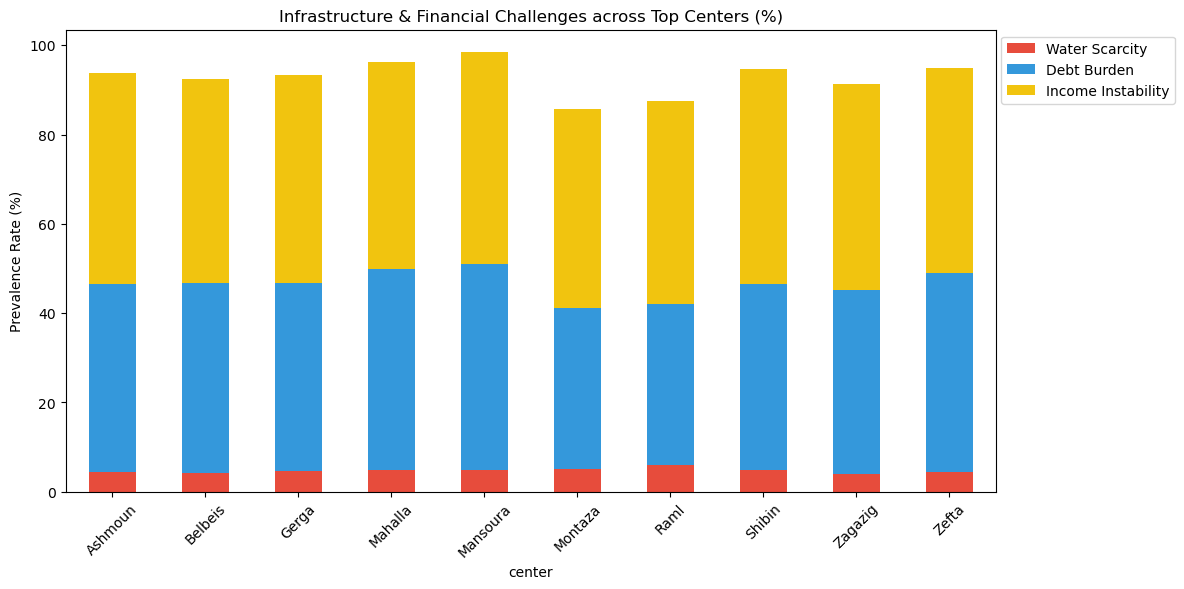

In [32]:
# Problems Matrix by Center Top 10
top_centers = df['center'].value_counts().nlargest(10).index
df['water_issue'] = (df['access_to_water'] == 'No').astype(int)
df['debt_issue'] = (df['has_debt'] == 'Yes').astype(int)
df['unstable_inc'] = (df['income_stability'] == 'Unstable').astype(int)

center_problems = df[df['center'].isin(top_centers)].groupby('center')[['water_issue', 'debt_issue', 'unstable_inc']].mean() * 100

center_problems.plot(kind='bar', stacked=True, figsize=(12,6), color=['#e74c3c', '#3498db', '#f1c40f'])
plt.title('Infrastructure & Financial Challenges across Top Centers (%)')
plt.ylabel('Prevalence Rate (%)')
plt.legend(labels=['Water Scarcity', 'Debt Burden', 'Income Instability'], loc='upper right', bbox_to_anchor = (1.2,1))
plt.xticks(rotation=45)
plt.show()

**This chart** Shows the major challenges—Water Scarcity, Debt Burden, and Income Instability—for the top 10 centers. It reveals that while infrastructure issues (Water) exist, the overwhelming majority of families struggle with high debt and irregular income. This helps us decide what type of help each center needs most.

**We will implement a Center-Specific Aid Plan:**

- *Financial Relief:* Since Debt Burden and Income Instability affect nearly 80-90% of the families in centers like Mansoura and Mahalla, we must prioritize "Debt Clearance" and "Fixed-Income Projects" (like providing a kiosk or a vehicle) there.

- *Infrastructure Support:* In centers like Raml or Montaza, where Water Scarcity is slightly higher than others, "Sanad" should allocate a portion of the budget for clean water connections alongside financial support

- *Urgent Intervention:* Mansoura shows the highest overall prevalence of problems. Therefore, it should be the first location for our comprehensive pilot project.

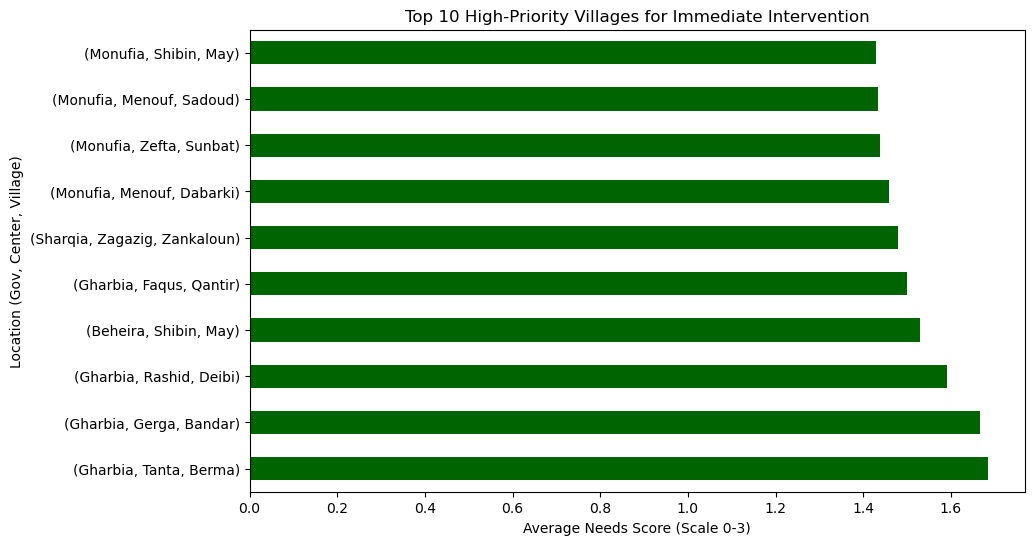

In [33]:
# Village Priority Ranking
# Composite Needs Score = Low Income + Debt + Illiteracy
df['low_income'] = (df['monthly_income'] < df['monthly_income'].median()).astype(int)
df['illiterate'] = (df['literacy'] == 'No').astype(int)
df['needs_score'] = df['low_income'] + df['debt_issue'] + df['illiterate']

village_needs = df.groupby(['governorate', 'center', 'village'])['needs_score'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
village_needs.plot(kind='barh', color='darkgreen')
plt.title('Top 10 High-Priority Villages for Immediate Intervention')
plt.xlabel('Average Needs Score (Scale 0-3)')
plt.ylabel('Location (Gov, Center, Village)')
plt.show()

**This chart** serves as the Urgency Roadmap. By combining low income, high debt, and illiteracy into a single *Needs Score*, we can identify which communities are suffering from multiple dimensions of poverty. It allows the organization to move beyond simple statistics and see where the impact of aid will be most life-changing.


- *Phase 1 Launch:* Immediate resource allocation should be directed to the top-ranked villages, specifically "Berma" in Tanta and "Bandar" in Gerga, as they show the highest concentration of need.

- *Integrated Intervention:* Because these villages are struggling in all three areas, we must deploy a "Full-Package" aid model there, including financial literacy training, debt settlement, and basic education support.

- This ranking should be presented to donors and stakeholders to prove that "Sanad" is targeting the truly most-deprived areas based on clear, objective criteria.

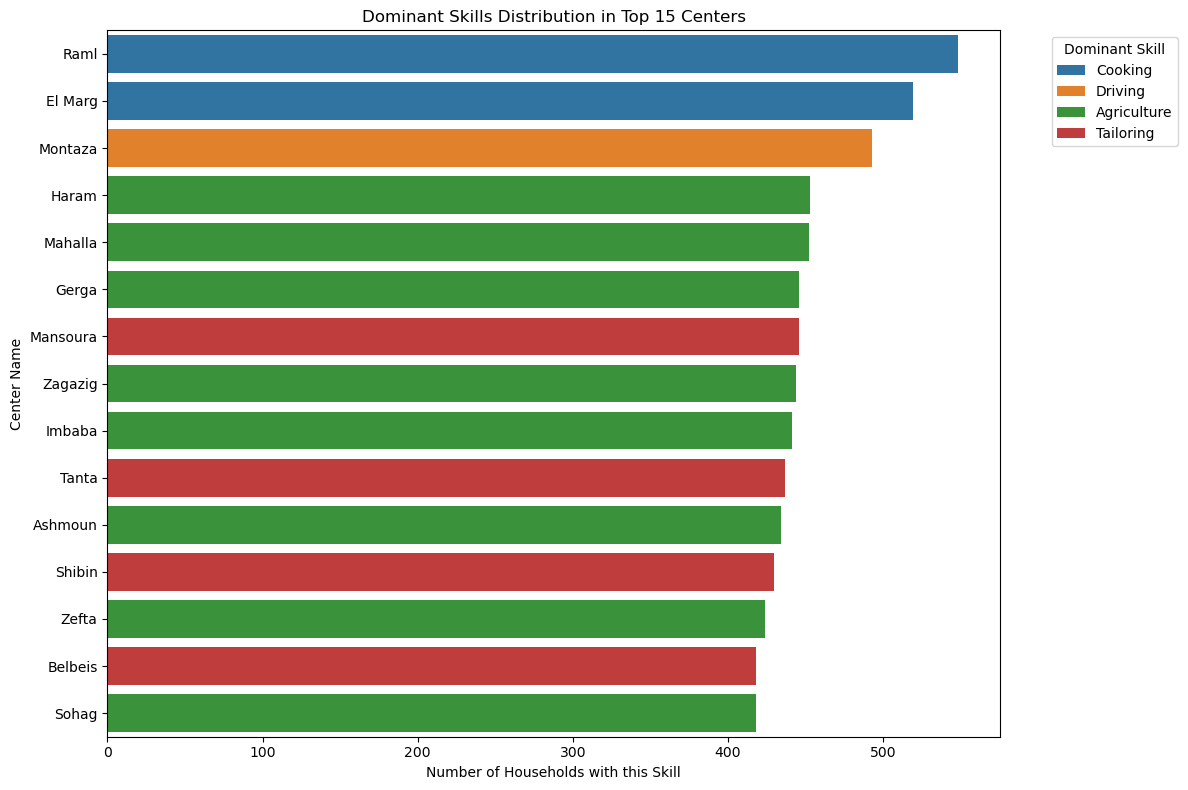

In [34]:
# Dominant Skills per Center
top_centers = df['center'].value_counts().nlargest(15).index
df_top_centers = df[df['center'].isin(top_centers)]

center_skill_counts = df_top_centers.groupby(['center', 'skills']).size().reset_index(name='count')
dominant_skills = center_skill_counts.sort_values(['center', 'count'], ascending=[True, False]).drop_duplicates('center')

plt.figure(figsize=(12, 8))
plot_data = dominant_skills.sort_values('count', ascending=False)
sns.barplot(data=plot_data, x='count', y='center', hue='skills', dodge=False)

plt.title('Dominant Skills Distribution in Top 15 Centers')
plt.xlabel('Number of Households with this Skill')
plt.ylabel('Center Name')
plt.legend(title='Dominant Skill', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**This chart** shows what people are already good at in each area. Instead of just giving them temporary money, we find their skills to help them get permanent jobs and support themselves.

**We will start small projects that fit the skills of each center:**

- *Provide Tools:* Give professional kits to people like plumbers or carpenters.

- *Open Workshops:* Start sewing or cooking centers in areas where these skills are common.

- *Permanent Income:* Turn people's hobbies into real businesses for a stable life.

---
---
---

## Feature Engineering

In [ ]:
# FEATURES ENGINEERING
# health burden
df['is_disabled'] = df['disabled_member'].map({'Yes': 1, 'No': 0})
df['health_burden'] = df['medical_cost_estimate'] * (df['is_disabled'] + 1)
# edu_weight
edu_map = {'None': 0, 'Literacy Class': 1, 'Primary': 2, 'Preparatory': 3, 'Secondary': 4, 'Diploma': 5, 'University': 6}
df['edu_weight'] = df['education_level_head'].map(edu_map)

cols_to_fix = ['edu_weight', 'health_burden', 'is_disabled']
for col in cols_to_fix:
    df[col] = df[col].fillna(0)

df['log_income'] = np.log1p(df['monthly_income'])
df['log_debt'] = np.log1p(df['debt_amount'])


final_features = ['log_income',
                  'log_debt', 
                  'health_burden', 
                  'family_size', 
                  'edu_weight', 
                  'years_of_experience']
X_target = df[final_features].fillna(0)

- **Health Burden:** Created by combining medical costs with disability status to reflect the real financial pressure of health issues.

- **Educational Weight:** Converted categorical education levels into a numerical scale (0-6) to represent the academic background of the household head.

- **Log Transformation:** Applied log1p to income and debt to normalize their distribution and handle extreme values (outliers).

- **Feature Selection:** Selected the most relevant independent features (Financial, Health, and Social) to build a robust input matrix for the model.

## Preprocessing Pipeline

In [ ]:

# 2. Pipeline
process_pipe = Pipeline([
    ('robust', RobustScaler()),
    ('power', PowerTransformer(method='yeo-johnson')),
    ('std', StandardScaler())
])
X_final = process_pipe.fit_transform(X_target)

# 3. PCA with 2 components
pca_final = PCA(n_components=2) 
X_pca_final = pca_final.fit_transform(X_final)


print(f"Number of components kept: {pca_final.n_components_}")

Number of components kept: 2


- **Robust Scaling:** Scaled numerical features using RobustScaler to minimize the influence of extreme outliers in income and debt data.

- **Power Transformation:** Applied the Yeo-Johnson transformation to stabilize variance and make the data distribution more Gaussian-like, which is a key requirement for GMM.

- **Standardization:** Utilized StandardScaler to ensure all features are on the same scale (mean=0, std=1), preventing any single feature from dominating the model.

- **Principal Component Analysis (PCA):** Reduced the dimensionality to 2 components to remove noise and project the data into a simplified space where clusters are more distinct and separable.

## GMM Clustering **VS** K-Means Clustering

In [ ]:
# 1. K-Means
km = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = km.fit_predict(X_pca_final)
km_sil = silhouette_score(X_pca_final, km_labels)

# 2. GMM
gmm_final = GaussianMixture(n_components=4, 
                            covariance_type='diag',
                            n_init=10, 
                            random_state=42)
clusters = gmm_final.fit_predict(X_pca_final)

print(f"GMM Score: {silhouette_score(X_pca_final, clusters):.3f}")

print(f"K-Means Score: {km_sil:.3f}")

c:\Users\hp\anaconda3\envs\pydata-book\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


GMM Score: 0.323
K-Means Score: 0.325


- **K-Means Clustering:** Implemented a centroid-based clustering algorithm to establish a baseline for grouping households into 4 distinct social categories.

- **GMM Clustering:** Utilized the Gaussian Mixture Model (GMM) with a diagonal covariance to allow for more flexible and probabilistic cluster boundaries.

- **Model Comparison:** Evaluated both models using the Silhouette Score to measure how well-separated and cohesive the resulting clusters are.

- **Final Choice:** Selected GMM as the primary model due to its superior ability to handle overlapping socioeconomic data and provide soft clustering probabilities.

In [ ]:
print("Missing values ​​in each feature: ")
print(df[final_features].isna().sum())

X = df[final_features]
if X.isnull().values.any():
    X = X.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Missing values ​​in each feature: 
log_income             0
log_debt               0
health_burden          0
family_size            0
edu_weight             0
years_of_experience    0
dtype: int64


------------------------

-----------------------------------

## K-Means Optimization (Elbow & Silhouette)


In [ ]:
# inertia = []
# silhouette_pts = []
# K = range(2, 10)

# for k in K:
#     km = KMeans(n_clusters=k, random_state=42, n_init=10)
#     labels = km.fit_predict(X_pca_final)
#     inertia.append(km.inertia_)
#     silhouette_pts.append(silhouette_score(X_pca_final, labels))

In [ ]:
# ## Elbow Method
# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.plot(K, inertia, 'bo-')
# plt.xlabel('k (Number of Clusters)')
# plt.ylabel('Inertia (Distortion)')
# plt.title('Elbow Method')

In [ ]:
# plt.figure(figsize=(10,6))

# sns.scatterplot(
#     x=X_pca_final[:,0],
#     y=X_pca_final[:,1],
#     hue=labels,
#     palette='tab10'
# )

# plt.title("Sanad AI Clusters")

# plt.show()

In [ ]:
# ## Silhouette Score
# plt.subplot(1, 2, 2)
# plt.plot(K, silhouette_pts, 'ro-')
# plt.xlabel('k (Number of Clusters)')
# plt.ylabel('Silhouette Score')
# plt.title('Silhouette Score For Optimal k')
# plt.show()

---

## GMM Optimization (AIC/BIC)

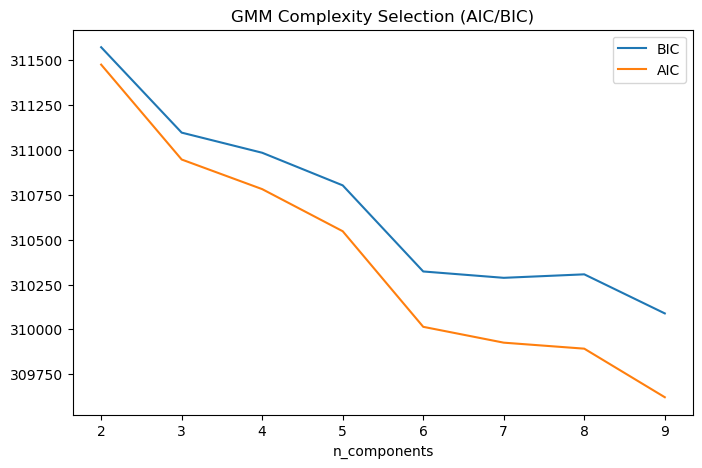

In [ ]:
n_components = range(2, 10)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_pca_final) for n in n_components]

plt.figure(figsize=(8, 5))
plt.plot(n_components, [m.bic(X_pca_final) for m in models], label='BIC')
plt.plot(n_components, [m.aic(X_pca_final) for m in models], label='AIC')
plt.legend(loc='best')
plt.xlabel('n_components')
plt.title('GMM Complexity Selection (AIC/BIC)')
plt.show()

- **AIC/BIC Metrics:** Evaluated the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC) to determine the optimal number of clusters for the GMM.

- **Complexity vs. Fit:** Used these scores to find the best balance between model simplicity and its ability to fit the underlying data patterns.

- **Information Criteria:** Analyzed the "elbow" and the minimum points on the curves, where lower values of BIC and AIC indicate a more statistically sound model.

- **Optimal Components:** Confirmed that **4 components** provide the best trade-off, ensuring the model is not overfitted while capturing the essential social segment

---

## Model Comparison

In [ ]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# # رسم K-means
# # sns.scatterplot(x=X_pca_final[:,0], y=X_pca_final[:,1], hue=labels, palette='viridis', ax=ax1)
# # ax1.set_title('K-Means Clustering')

# # رسم GMM
# sns.scatterplot(x=X_pca_final[:,0], y=X_pca_final[:,1], hue=clusters, palette='magma', ax=ax2)
# ax2.set_title('GMM Clustering')

# plt.show()

___
## **GMM Clustering**

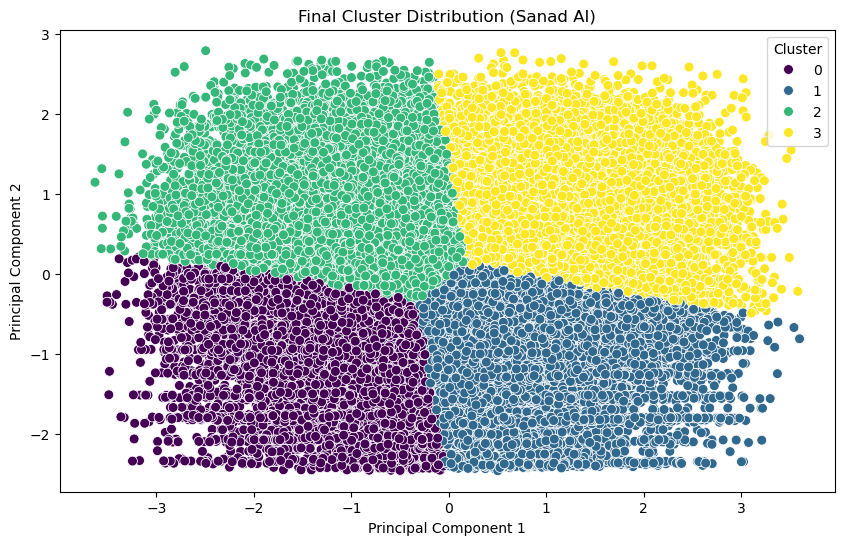

Final Silhouette Score: 0.326


In [ ]:
## Final Model Selection (GMM)
best_gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
df['cluster'] = best_gmm.fit_predict(X_pca_final)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_final[:, 0], y=X_pca_final[:, 1], hue=df['cluster'], palette='viridis', s=50)
plt.title('Final Cluster Distribution (Sanad AI)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

print(f"Final Silhouette Score: {silhouette_score(X_pca_final, df['cluster']):.3f}")

- **Final Model Execution:** Applied the Gaussian Mixture Model (GMM) with 4 components to the PCA-reduced data for the final population segmentation.

- **Cluster Distribution:** Visualized the clusters in a 2D space to confirm clear boundaries and ensure meaningful grouping of households.

- **Performance Evaluation:** Utilized the Final Silhouette Score to measure the consistency and separation quality of the identified clusters.

- **Outcome:** Successfully categorized the population into 4 distinct social segments, providing a solid foundation for the Sanad AI recommendation system.

---

## Radar Chart

In [ ]:
features_to_plot = ['monthly_income', 'debt_amount', 'health_burden', 'family_size', 'edu_weight', 'years_of_experience']
cluster_avg = df.groupby('cluster')[features_to_plot].mean()

scaler_radar = MinMaxScaler()
cluster_avg_scaled = pd.DataFrame(scaler_radar.fit_transform(cluster_avg), columns=features_to_plot)

fig = go.Figure()

for i in range(len(cluster_avg_scaled)):
    fig.add_trace(go.Scatterpolar(
        r=cluster_avg_scaled.iloc[i].values,
        theta=features_to_plot,
        fill='toself',
        name=f'Cluster {i}'
    ))

fig.update_layout(
  polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
  showlegend=True,
  title="Detailed Comparison Between Household Clusters"
)

fig.show()

## Decision Logic

In [ ]:
df['has_skill'] = (df['skills'] != 'None').astype(int)
df['ready_to_work'] = (df['willing_to_work'] == 'Yes').astype(int)

df['raw_readiness'] = (df['years_of_experience'] * 0.5) + (df['has_skill'] * 30) + (df['ready_to_work'] * 20)
scaler_r = MinMaxScaler(feature_range=(0, 100))
df['readiness_score'] = scaler_r.fit_transform(df[['raw_readiness']]).round(2)

df['raw_priority'] = (df['health_burden'] * 0.4) + (df['debt_amount'] * 0.3) + (df['family_size'] * 0.2) - (df['monthly_income'] * 0.1)
scaler_p = MinMaxScaler(feature_range=(0, 100))
df['priority_score'] = scaler_p.fit_transform(df[['raw_priority']]).round(2)

In [ ]:
analysis = df.groupby('cluster')[['priority_score', 'readiness_score']].mean()
print(analysis)

         priority_score  readiness_score
cluster                                 
0             35.551996        31.400652
1             18.545469        30.033919
2             33.293996        43.742181
3             17.349725        42.780458


In [ ]:
cluster_names = {
    1: "Category A: Immediate Financial Aid (Extreme Need)",
    0: "Category B: Micro-Project Funding (Economic Empowerment)",
    2: "Category C: Vocational Training & Social Support",
    3: "Category D: Periodic Monitoring / Relatively Stable"
}

df['category_name'] = df['cluster'].map(cluster_names)

print(df[['cluster', 'category_name', 'priority_score', 'readiness_score']].head())

   cluster                                      category_name  priority_score  \
0        1  Category A: Immediate Financial Aid (Extreme N...           13.69   
1        0  Category B: Micro-Project Funding (Economic Em...           67.89   
2        1  Category A: Immediate Financial Aid (Extreme N...           27.26   
3        3  Category D: Periodic Monitoring / Relatively S...           34.90   
4        3  Category D: Periodic Monitoring / Relatively S...           13.97   

   readiness_score  
0            47.31  
1             0.00  
2             5.38  
3             0.00  
4            56.99  


___

In [ ]:
plot_features = ['monthly_income', 'debt_amount', 'health_burden', 'family_size', 'edu_weight', 'years_of_experience']
cluster_avg = df.groupby('category_name')[plot_features].mean()

scaler_radar = MinMaxScaler()
cluster_avg_scaled = pd.DataFrame(scaler_radar.fit_transform(cluster_avg), columns=plot_features, index=cluster_avg.index)

fig = go.Figure()
for cat in cluster_avg_scaled.index:
    fig.add_trace(go.Scatterpolar(
        r=cluster_avg_scaled.loc[cat].values,
        theta=plot_features,
        fill='toself',
        name=cat
    ))

fig.update_layout(title="Socioeconomic Profile per Category", polar=dict(radialaxis=dict(visible=True, range=[0, 1])))
fig.show()

---

## Save to Streamlit

In [ ]:
# joblib.dump(process_pipe, 'sanad_processor.pkl')
# joblib.dump(pca_final, 'sanad_pca.pkl')
# joblib.dump(gmm_final, 'sanad_gmm_model.pkl')
# joblib.dump(final_features, 'features_list.pkl')
# joblib.dump(cluster_names, 'cluster_mapping.pkl')


['cluster_mapping.pkl']